# Supplementary Materials LaTeX Document: Extended Evidence Tables & Reviewer Objection Matrix

This notebook demonstrates the **supplementary materials compilation evaluation** from the Circuit Motif Spectroscopy project.

**What this artifact does:**
- Loads evaluation output data compiled from 6 JSON experiment dependencies
- Demonstrates LaTeX formatting helpers for scientific tables (p-values, Z-scores, effect sizes)
- Builds structured LaTeX table content from evidence data
- Analyzes section word counts, evidence completeness, and reviewer objection severity
- Visualizes key metrics: section word distributions, hypothesis coverage, and objection risk assessment

**Data:** Evaluation output with 3 datasets — section word counts (8 sections), master evidence table (59 rows across H1–H5), and reviewer objection matrix (12 entries).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter7_supplementary_m/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Top-level keys: {list(data.keys())}")
print(f"Datasets: {[ds['dataset'] for ds in data['datasets']]}")
print(f"Metrics: {json.dumps(data['metrics_agg'], indent=2)}")

Top-level keys: ['metadata', 'metrics_agg', 'datasets']
Datasets: ['section_word_counts', 'master_evidence_table', 'reviewer_objections']
Metrics: {
  "compilation_success": 1,
  "page_count": 13,
  "total_evidence_rows": 59,
  "reviewer_objections_count": 12,
  "limitations_count": 10,
  "domain_breakdown_completeness": 1.0,
  "ablation_table_completeness": 1.0,
  "total_section_words": 2609
}


## Configuration

Tunable parameters controlling the demo scope.

In [5]:
# --- Config ---
# Maximum evidence rows to process in LaTeX table demo
MAX_EVIDENCE_ROWS = 18  # original: 59
# Maximum reviewer objections to display
MAX_OBJECTIONS = 12  # original: 12
# Truncation length for table cell text
TRUNCATE_LEN = 60  # original: 60

## LaTeX Formatting Helpers

These helper functions format numeric values (p-values, Z-scores, effect sizes) for LaTeX tables. They handle `None` values, scientific notation for tiny p-values, and LaTeX special character escaping.

In [6]:
def escape_latex(text: str) -> str:
    """Escape LaTeX special characters in text from JSON."""
    if not isinstance(text, str):
        text = str(text)
    replacements = [
        ("\\", "\\textbackslash{}"),
        ("&", "\\&"),
        ("%", "\\%"),
        ("$", "\\$"),
        ("#", "\\#"),
        ("_", "\\_"),
        ("{", "\\{"),
        ("}", "\\}"),
        ("~", "\\textasciitilde{}"),
        ("^", "\\textasciicircum{}"),
        ("<", "\\textless{}"),
        (">", "\\textgreater{}"),
    ]
    for old, new in replacements:
        text = text.replace(old, new)
    return text


def fmt_pval_raw(p) -> str:
    """Format p-value for LaTeX (no $ delimiters, for use inside math mode)."""
    if p is None:
        return "\\text{---}"
    try:
        p = float(p)
    except (TypeError, ValueError):
        return "\\text{" + escape_latex(str(p)) + "}"
    if p == 0.0:
        return "<10^{-300}"
    if p < 0.001:
        exp = math.floor(math.log10(abs(p)))
        mantissa = p / (10 ** exp)
        return f"{mantissa:.2f} \\times 10^{{{exp}}}"
    return f"{p:.3f}"


def fmt_pval(p) -> str:
    """Format p-value for LaTeX (with $ delimiters)."""
    if p is None:
        return "---"
    raw = fmt_pval_raw(p)
    return f"${raw}$"


def fmt_z(val) -> str:
    """Format Z-score (1 decimal)."""
    if val is None:
        return "---"
    try:
        return f"{float(val):.1f}"
    except (TypeError, ValueError):
        return str(val)


def fmt_val(val, digits: int = 2) -> str:
    """Format a numeric value with specified significant digits."""
    if val is None:
        return "---"
    try:
        v = float(val)
        if abs(v) >= 1000:
            return f"{v:,.0f}"
        if abs(v) >= 1:
            return f"{v:.{digits}f}"
        if v == 0.0:
            return "0"
        if abs(v) >= 0.001:
            return f"{v:.{digits+1}f}"
        return fmt_pval(v)
    except (TypeError, ValueError):
        return str(val)


def truncate(text: str, max_len: int = 60) -> str:
    """Truncate text for table cells."""
    if not text:
        return ""
    if len(text) <= max_len:
        return text
    return text[:max_len - 3] + "..."


# Quick test of formatting helpers
print("P-value formatting examples:")
for p in [None, 0.0, 1.2e-15, 0.0003, 0.045, 0.5]:
    print(f"  p={p!s:>12s}  →  {fmt_pval(p)}")
print(f"\nZ-score: {fmt_z(46.2066)}")
print(f"Value:   {fmt_val(0.000123, 3)}")
print(f"Escaped: {escape_latex('H1: Z > 2 & p < 0.05')}")

P-value formatting examples:
  p=        None  →  ---
  p=         0.0  →  $<10^{-300}$
  p=     1.2e-15  →  $1.20 \times 10^{-15}$
  p=      0.0003  →  $3.00 \times 10^{-4}$
  p=       0.045  →  $0.045$
  p=         0.5  →  $0.500$

Z-score: 46.2
Value:   $1.23 \times 10^{-4}$
Escaped: H1: Z \textgreater{} 2 \& p \textless{} 0.05


## Extract Datasets

Parse the three datasets from the loaded evaluation output: section word counts, master evidence table, and reviewer objection matrix.

In [7]:
# Extract datasets by name
datasets_by_name = {ds["dataset"]: ds["examples"] for ds in data["datasets"]}

section_wc = datasets_by_name["section_word_counts"]
evidence_rows = datasets_by_name["master_evidence_table"][:MAX_EVIDENCE_ROWS]
reviewer_objs = datasets_by_name["reviewer_objections"][:MAX_OBJECTIONS]

print(f"Section word counts:  {len(section_wc)} sections")
print(f"Evidence rows:        {len(evidence_rows)} rows (of {data['metrics_agg']['total_evidence_rows']} total)")
print(f"Reviewer objections:  {len(reviewer_objs)} entries")

# Parse the nested JSON output field for evidence rows
evidence_parsed = []
for row in evidence_rows:
    parsed = json.loads(row["output"])
    parsed["_eval_criterion_met"] = row.get("eval_criterion_met", 0)
    parsed["_eval_value"] = row.get("eval_value", 0.0)
    evidence_parsed.append(parsed)

# Parse reviewer objections
objections_parsed = []
for obj in reviewer_objs:
    objections_parsed.append(json.loads(obj["output"]))

print(f"\nFirst evidence row keys: {list(evidence_parsed[0].keys())}")
print(f"First objection keys:   {list(objections_parsed[0].keys())}")

Section word counts:  8 sections
Evidence rows:        18 rows (of 59 total)
Reviewer objections:  12 entries

First evidence row keys: ['row_id', 'hypothesis', 'sub_claim', 'primary_metric', 'value', 'ci_95_lower', 'ci_95_upper', 'p_value', 'effect_size_type', 'effect_size_value', 'success_criterion', 'criterion_met', 'iteration', 'artifact_source', 'key_caveat', '_eval_criterion_met', '_eval_value']
First objection keys:   ['objection_id', 'objection', 'severity', 'evidence_based_response', 'supporting_artifacts', 'residual_risk', 'mitigation_action']


## Build LaTeX Evidence Table

Demonstrates how the original script constructs a LaTeX `longtable` from evidence rows — formatting p-values in scientific notation, computing confidence intervals, and marking criterion pass/fail with checkmarks.

In [8]:
def build_evidence_table_latex(rows):
    """Build LaTeX longtable content from evidence rows (mirrors build_s2_evidence_table)."""
    lines = []
    lines.append(r"\section{Full Evidence Table}")
    lines.append(r"\begin{longtable}{rlp{3.2cm}p{3cm}rrrrp{1.5cm}l}")
    lines.append(r"\caption{Master Evidence Table: evidence rows across hypotheses H1--H5.}\label{tab:evidence}\\")
    lines.append(r"\toprule")
    lines.append(r"\# & Hyp & Sub-claim & Primary Metric & Value & 95\% CI & p-value & Effect Size & Criterion & Met \\")
    lines.append(r"\midrule")
    lines.append(r"\endfirsthead")

    prev_hyp = None
    for i, row in enumerate(rows):
        hyp = row.get("hypothesis", "")
        if prev_hyp and hyp != prev_hyp:
            lines.append(r"\midrule")
        prev_hyp = hyp

        if i % 2 == 0:
            lines.append(r"\rowcolor{rowgray}")

        row_id = row.get("row_id", i + 1)
        sub_claim = escape_latex(truncate(str(row.get("sub_claim", "")), 45))
        metric = escape_latex(truncate(str(row.get("primary_metric", "")), 40))
        value = fmt_val(row.get("value"), 4)

        ci_lo = row.get("ci_95_lower")
        ci_hi = row.get("ci_95_upper")
        if ci_lo is not None and ci_hi is not None:
            ci_str = f"[{fmt_val(ci_lo, 3)}, {fmt_val(ci_hi, 3)}]"
        else:
            ci_str = "---"

        pval = fmt_pval(row.get("p_value"))

        es_type = row.get("effect_size_type", "")
        es_val = row.get("effect_size_value")
        if es_val is not None:
            es_str = f"{escape_latex(str(es_type)[:8])}={fmt_val(es_val, 3)}"
        else:
            es_str = "---"

        criterion = escape_latex(truncate(str(row.get("success_criterion", "")), 20))
        met = row.get("criterion_met", False)
        met_str = r"$\checkmark$" if met else r"$\times$"

        lines.append(
            f"{row_id} & {escape_latex(hyp)} & {sub_claim} & {metric} & "
            f"{value} & {ci_str} & {pval} & {es_str} & {criterion} & {met_str} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{longtable}")
    return "\n".join(lines)


latex_evidence = build_evidence_table_latex(evidence_parsed)
print(f"Generated {len(latex_evidence)} chars of LaTeX ({len(evidence_parsed)} rows)")
print("\n--- First 800 chars of generated LaTeX ---")
print(latex_evidence[:800])

Generated 3649 chars of LaTeX (18 rows)

--- First 800 chars of generated LaTeX ---
\section{Full Evidence Table}
\begin{longtable}{rlp{3.2cm}p{3cm}rrrrp{1.5cm}l}
\caption{Master Evidence Table: evidence rows across hypotheses H1--H5.}\label{tab:evidence}\\
\toprule
\# & Hyp & Sub-claim & Primary Metric & Value & 95\% CI & p-value & Effect Size & Criterion & Met \\
\midrule
\endfirsthead
\rowcolor{rowgray}
1 & H1 & FFL (030T) overrepresented across all attr... & FFL mean Z-score (200 graphs, 50 null... & 46.2066 & --- & --- & Z-score=46.207 & Mean Z \textgreater{} 2 & $\checkmark$ \\
2 & H1 & FFL overrepresentation in antonym domain & FFL median Z-score (antonym) & 26.2773 & --- & --- & Z-score=26.277 & Domain median Z \textgreater{} 2 & $\checkmark$ \\
\rowcolor{rowgray}
3 & H1 & FFL overrepresentation in arithmetic domain & FFL median Z-score (arithmetic) & 55.3803 & --


## Build Reviewer Objection-Response Matrix

Constructs the LaTeX table for anticipated reviewer objections with severity ratings, evidence-based responses, and residual risk assessment.

In [9]:
def severity_color(sev: int) -> str:
    """Return LaTeX color for severity 1-5."""
    if sev >= 4:
        return "red!20"
    if sev == 3:
        return "orange!20"
    return "green!20"


def risk_color(risk: str) -> str:
    """Return LaTeX color for residual risk."""
    r = str(risk).lower()
    if r == "high":
        return "red!20"
    if r == "medium":
        return "orange!20"
    return "green!20"


def build_reviewer_matrix_latex(objections):
    """Build LaTeX longtable for reviewer objection-response matrix."""
    lines = []
    lines.append(r"\section{Reviewer Objection-Response Matrix}")
    lines.append(r"\small")
    lines.append(r"\begin{longtable}{rp{3cm}cp{5.5cm}p{2cm}c}")
    lines.append(r"\caption{Reviewer Objection-Response Matrix.}\label{tab:reviewer}\\")
    lines.append(r"\toprule")
    lines.append(r"\# & Objection & Sev. & Evidence-Based Response & Artifacts & Risk \\")
    lines.append(r"\midrule")
    lines.append(r"\endfirsthead")

    for obj in objections:
        oid = obj.get("objection_id", "")
        otxt = escape_latex(truncate(str(obj.get("objection", "")), 80))
        sev = obj.get("severity", 3)
        sev_col = severity_color(sev)
        resp = escape_latex(truncate(str(obj.get("evidence_based_response", "")), 150))
        arts = obj.get("supporting_artifacts", [])
        arts_str = escape_latex(", ".join(str(a) for a in arts) if arts else "---")
        risk = str(obj.get("residual_risk", "medium"))
        risk_col = risk_color(risk)

        lines.append(
            f"{oid} & \\textit{{{otxt}}} & "
            f"\\cellcolor{{{sev_col}}}{sev} & "
            f"{resp} & {arts_str} & "
            f"\\cellcolor{{{risk_col}}}{escape_latex(risk)} \\\\"
        )
        lines.append(r"\midrule")

    lines.append(r"\end{longtable}")
    lines.append(r"\normalsize")
    return "\n".join(lines)


latex_reviewer = build_reviewer_matrix_latex(objections_parsed)
print(f"Generated {len(latex_reviewer)} chars of LaTeX ({len(objections_parsed)} objections)")
print("\n--- First 600 chars ---")
print(latex_reviewer[:600])

Generated 4355 chars of LaTeX (12 objections)

--- First 600 chars ---
\section{Reviewer Objection-Response Matrix}
\small
\begin{longtable}{rp{3cm}cp{5.5cm}p{2cm}c}
\caption{Reviewer Objection-Response Matrix.}\label{tab:reviewer}\\
\toprule
\# & Objection & Sev. & Evidence-Based Response & Artifacts & Risk \\
\midrule
\endfirsthead
1 & \textit{Motifs are just proxies for graph statistics — the high shared variance (93\%)...} & \cellcolor{red!20}4 & While 93\% of variance is shared, unique motif R-squared=0.0184 with CI [0.0213, 0.0448] strictly excludes zero. Residualized NMI=0.264 (p=0.001) co... & exp\_id1\_it5 & \cellcolor{orange!20}medium \\
\midrule
2 & \t


## Section Word Count Analysis

Count words per section by stripping LaTeX commands — used to verify all 8 supplementary sections (S1–S8) have substantive content.

In [10]:
def count_section_words(tex_content: str) -> dict:
    """Count words per section by stripping LaTeX commands."""
    sections = {}
    current = None
    current_text = []

    for line in tex_content.split("\n"):
        m = re.match(r"\\section\{(.+?)\}", line)
        if m:
            if current:
                sections[current] = current_text
            current = m.group(1)
            current_text = []
        elif current:
            current_text.append(line)

    if current:
        sections[current] = current_text

    word_counts = {}
    for i, (sec_name, sec_lines) in enumerate(sections.items(), 1):
        text = "\n".join(sec_lines)
        # Strip LaTeX commands
        text = re.sub(r"\\[a-zA-Z]+(\{[^}]*\})*(\[[^\]]*\])*", " ", text)
        text = re.sub(r"[{}\\$&%#_^~]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        words = len(text.split()) if text else 0
        word_counts[f"S{i}"] = words
    return word_counts


# Use pre-computed section word counts from the evaluation metadata
section_word_counts = data["metadata"]["section_word_counts"]
print("Section Word Counts (from compiled supplementary):")
print("-" * 40)

section_labels = {
    "S1": "Extended Methods",
    "S2": "Full Evidence Table",
    "S3": "Per-Domain Z-Scores",
    "S4": "Ablation Results",
    "S5": "Failure Prediction",
    "S6": "Statistical Framework",
    "S7": "Reviewer Objections",
    "S8": "Limitations",
}

table_data = []
for sec_key, wc in section_word_counts.items():
    label = section_labels.get(sec_key, sec_key)
    table_data.append([sec_key, label, wc])

print(tabulate(table_data, headers=["Section", "Title", "Words"], tablefmt="grid"))
print(f"\nTotal words: {sum(section_word_counts.values())}")

# Also demonstrate word counting on our generated LaTeX
demo_wc = count_section_words(latex_evidence + "\n" + latex_reviewer)
print(f"\nDemo LaTeX word counts: {demo_wc}")

Section Word Counts (from compiled supplementary):
----------------------------------------
+-----------+-----------------------+---------+
| Section   | Title                 |   Words |
+===========+=======================+=========+
| S1        | Extended Methods      |     240 |
+-----------+-----------------------+---------+
| S2        | Full Evidence Table   |    1202 |
+-----------+-----------------------+---------+
| S3        | Per-Domain Z-Scores   |     161 |
+-----------+-----------------------+---------+
| S4        | Ablation Results      |     146 |
+-----------+-----------------------+---------+
| S5        | Failure Prediction    |     265 |
+-----------+-----------------------+---------+
| S6        | Statistical Framework |     184 |
+-----------+-----------------------+---------+
| S7        | Reviewer Objections   |     377 |
+-----------+-----------------------+---------+
| S8        | Limitations           |      34 |
+-----------+-----------------------+-------

## Compute Output Metrics

Build the evaluation output summary — compilation status, completeness scores, and aggregate statistics matching the original `build_output()` function.

In [11]:
# Reproduce the metrics computation from the original eval script
metrics_agg = data["metrics_agg"]
metadata = data["metadata"]

# Evidence table analysis
n_criteria_met = sum(1 for r in evidence_parsed if r.get("criterion_met", False))
n_criteria_total = len(evidence_parsed)
criterion_pass_rate = n_criteria_met / n_criteria_total if n_criteria_total > 0 else 0

# Hypothesis breakdown
hyp_counts = Counter(r.get("hypothesis", "?") for r in evidence_parsed)
hyp_pass = Counter(r.get("hypothesis", "?") for r in evidence_parsed if r.get("criterion_met"))

# Reviewer severity analysis
sev_counts = Counter(o.get("severity", 0) for o in objections_parsed)
risk_counts = Counter(o.get("residual_risk", "unknown") for o in objections_parsed)

print("=== Evaluation Output Metrics ===")
print(f"Compilation success: {metadata['compilation_success']}")
print(f"Page count:          {metadata['page_count']}")
print(f"Domain breakdown completeness: {metrics_agg['domain_breakdown_completeness']:.1%}")
print(f"Ablation table completeness:   {metrics_agg['ablation_table_completeness']:.1%}")
print()
print(f"Evidence rows (demo subset): {n_criteria_total}")
print(f"  Criteria met: {n_criteria_met}/{n_criteria_total} ({criterion_pass_rate:.1%})")
print(f"  By hypothesis: {dict(hyp_counts)}")
print(f"  Pass by hypothesis: {dict(hyp_pass)}")
print()
print(f"Reviewer objections: {len(objections_parsed)}")
print(f"  Severity distribution: {dict(sorted(sev_counts.items()))}")
print(f"  Residual risk: {dict(risk_counts)}")

=== Evaluation Output Metrics ===
Compilation success: True
Page count:          13
Domain breakdown completeness: 100.0%
Ablation table completeness:   100.0%

Evidence rows (demo subset): 18
  Criteria met: 10/18 (55.6%)
  By hypothesis: {'H1': 6, 'H2': 3, 'H3': 3, 'H4': 3, 'H5': 3}
  Pass by hypothesis: {'H1': 3, 'H2': 2, 'H4': 3, 'H5': 2}

Reviewer objections: 12
  Severity distribution: {2: 1, 3: 6, 4: 5}
  Residual risk: {'medium': 6, 'low': 4, 'high': 2}


## Visualization

Four-panel summary: (1) section word count distribution, (2) evidence values by hypothesis with pass/fail markers, (3) reviewer objection severity vs. residual risk, and (4) hypothesis criterion pass rates.

/tmp/ipykernel_466/4156740831.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(h, val, c=hyp_colors.get(h, "gray"), marker=marker,
/tmp/ipykernel_466/4156740831.py:34: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([], [], c="gray", marker="x", s=60, label="Criterion Not Met", edgecolors="black")


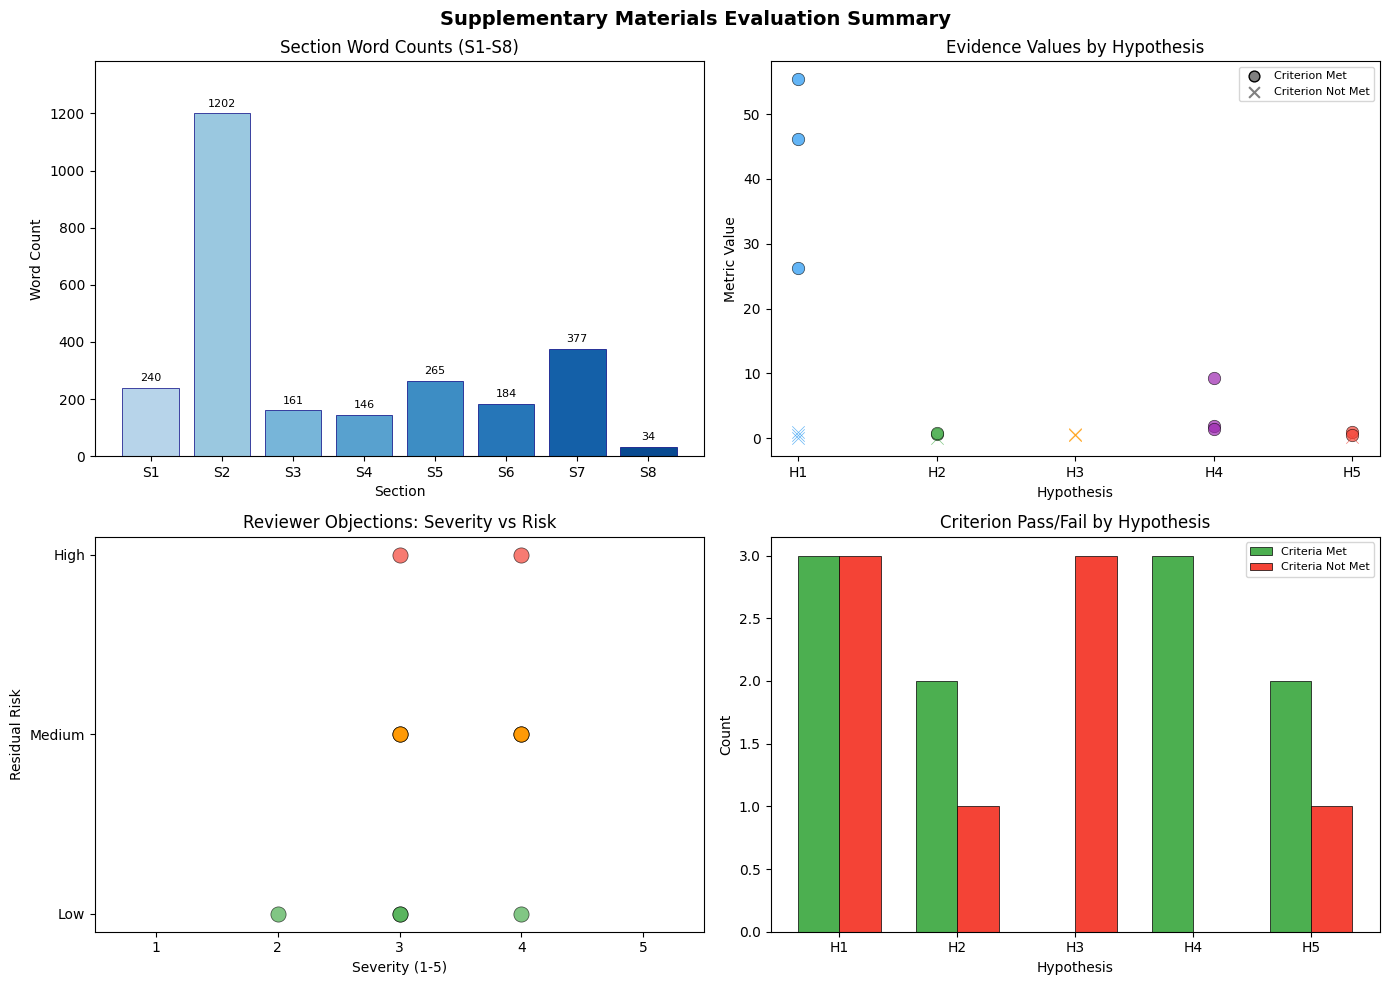

Saved: supplementary_eval_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Supplementary Materials Evaluation Summary", fontsize=14, fontweight="bold")

# --- Panel 1: Section Word Counts ---
ax = axes[0, 0]
sections = list(section_word_counts.keys())
words = list(section_word_counts.values())
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(sections)))
bars = ax.bar(sections, words, color=colors, edgecolor="navy", linewidth=0.5)
ax.set_xlabel("Section")
ax.set_ylabel("Word Count")
ax.set_title("Section Word Counts (S1-S8)")
for bar, w in zip(bars, words):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(w), ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, max(words) * 1.15)

# --- Panel 2: Evidence Values by Hypothesis ---
ax = axes[0, 1]
hyp_labels = sorted(set(r.get("hypothesis", "?") for r in evidence_parsed))
hyp_colors = {"H1": "#2196F3", "H2": "#4CAF50", "H3": "#FF9800", "H4": "#9C27B0", "H5": "#F44336"}
for r in evidence_parsed:
    h = r.get("hypothesis", "?")
    val = r.get("_eval_value", 0)
    met = r.get("criterion_met", False)
    marker = "o" if met else "x"
    ax.scatter(h, val, c=hyp_colors.get(h, "gray"), marker=marker,
               s=80, alpha=0.7, edgecolors="black", linewidths=0.5)
ax.set_xlabel("Hypothesis")
ax.set_ylabel("Metric Value")
ax.set_title("Evidence Values by Hypothesis")
# Legend for pass/fail
ax.scatter([], [], c="gray", marker="o", s=60, label="Criterion Met", edgecolors="black")
ax.scatter([], [], c="gray", marker="x", s=60, label="Criterion Not Met", edgecolors="black")
ax.legend(loc="upper right", fontsize=8)

# --- Panel 3: Reviewer Severity vs Risk ---
ax = axes[1, 0]
risk_order = {"low": 0, "medium": 1, "high": 2}
risk_colors_map = {"low": "#4CAF50", "medium": "#FF9800", "high": "#F44336"}
for obj in objections_parsed:
    sev = obj.get("severity", 3)
    risk = str(obj.get("residual_risk", "medium")).lower()
    rx = risk_order.get(risk, 1)
    ax.scatter(sev, rx, c=risk_colors_map.get(risk, "gray"),
               s=120, alpha=0.7, edgecolors="black", linewidths=0.5)
ax.set_xlabel("Severity (1-5)")
ax.set_ylabel("Residual Risk")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Low", "Medium", "High"])
ax.set_title("Reviewer Objections: Severity vs Risk")
ax.set_xlim(0.5, 5.5)

# --- Panel 4: Hypothesis Pass Rates ---
ax = axes[1, 1]
hyps = sorted(hyp_counts.keys())
total_counts = [hyp_counts[h] for h in hyps]
pass_counts = [hyp_pass.get(h, 0) for h in hyps]
fail_counts = [t - p for t, p in zip(total_counts, pass_counts)]
x_pos = np.arange(len(hyps))
bar_w = 0.35
ax.bar(x_pos - bar_w/2, pass_counts, bar_w, label="Criteria Met", color="#4CAF50", edgecolor="black", linewidth=0.5)
ax.bar(x_pos + bar_w/2, fail_counts, bar_w, label="Criteria Not Met", color="#F44336", edgecolor="black", linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(hyps)
ax.set_xlabel("Hypothesis")
ax.set_ylabel("Count")
ax.set_title("Criterion Pass/Fail by Hypothesis")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("supplementary_eval_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: supplementary_eval_summary.png")